# 영화 리뷰의 호불호 분포

1. **데이터 로드**
   - Daksh0505/IMDB-Reviews (movie_id, review, rating 1~10)

2. **전처리**
   - 영화별 평균 평점 계산 → 3구간 분류 (저평점/중간/고평점)
   - 리뷰 20개 미만 영화 제거 → 140개 영화, 108,062개 리뷰

3. **감성 분석** `text-classification`
   - GoEmotions 모델로 리뷰별 polarity_score 계산
   - polarity_score = 긍정 확률 합 - 부정 확률 합 (-1 ~ +1)

4. **집계**
   - 영화별 rating 분산 + polarity 분산 계산
   - Robust Scaling 정규화 후 평균 → controversy_score 산출

5. **시각화**
   - 구간별 controversy_score 박스플롯
   - rating 분산 vs polarity 분산 산점도

6. **결과 해석**

## 한글 폰트 설정

Matplotlib에서 한글 폰트가 깨지는 문제를 해결하기 위해 '나눔 고딕' 폰트를 설치하고 설정합니다.

In [1]:
# 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 폰트 설정 및 리로드
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print('한글 폰트 설정 완료')

한글 폰트 설정 완료


In [8]:
!pip install -q transformers datasets torch pandas matplotlib seaborn

In [9]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print(f"device: {'GPU (cuda:0)' if device == 0 else 'CPU'}")

device: GPU (cuda:0)


## 데이터셋 로드 및 준비

- Daksh0505/IMDB-Reviews
  - **구성**: IMDB에서 수집한 146개 영화, 113,538개 리뷰
  - **주요 컬럼**: `movie_id`, `review`(텍스트), `rating`(1~10 숫자)
  - **선택 이유**: **영화 단위로 리뷰를 묶어 분산을 계산**하는 것이 목적 ➡️ `movie_id` + 숫자 평점(1~10) + 리뷰를 동시에 제공하는 데이터셋이 필요



In [7]:
from google.colab import userdata
import huggingface_hub

# Colab Secrets에서 토큰 가져오기
hf_token = userdata.get('HF_TOKEN')

# Hugging Face 로그인
huggingface_hub.login(token=hf_token)

In [8]:
ds = load_dataset("Daksh0505/IMDB-Reviews", streaming=True)

records = []
for item in ds['train']:
    reviews = item['reviews']
    if isinstance(reviews, dict):
        records.append({
            'movie_id': item['movie_id'],
            'title': reviews.get('title', ''),
            'review': reviews.get('review', ''),
            'rating': reviews.get('rating', '')
        })
    elif isinstance(reviews, list):
        for r in reviews:
            records.append({
                'movie_id': item['movie_id'],
                'title': r.get('title', ''),
                'review': r.get('review', ''),
                'rating': r.get('rating', '')
            })

df_raw = pd.DataFrame(records)
print(f"로드 완료: {len(df_raw)}행")
print(df_raw.head(3))

Resolving data files:   0%|          | 0/146 [00:00<?, ?it/s]

로드 완료: 113538행
    movie_id                                              title  \
0  tt0058548         People Need To Lighten Up About This Movie   
1  tt0058548  Not NEARLY as bad as people make it out to be....   
2  tt0058548        Can something this dumb really be harmless?   

                                              review rating  
0  This is certainly a consensus pick as one of t...      4  
1  I still very much appreciate its spirit, both ...      4  
2  Maybe I have a soft spot somewhere in my heart...      4  


## 전처리

In [ ]:
# 1. [No Rating] 제거 및 rating 숫자 변환
df = df_raw[df_raw['rating'] != '[No Rating]'].copy()
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# 2. 결측치 및 빈 리뷰 제거
df = df.dropna(subset=['rating', 'review'])
df = df[df['review'].str.strip() != '']

# 3. 영화별 평균 평점 계산
movie_avg = df.groupby('movie_id')['rating'].mean().rename('rating_movie_avg')
df = df.join(movie_avg, on='movie_id')

# 4. 영화 평점 구간 분류 (3구간)
def rating_to_group(r):
    r = int(r)
    if r <= 4:   return '저평점 (1-4)'
    elif r <= 7: return '중간 (5-7)'
    else:        return '고평점 (8-10)'

df['movie_rating_group'] = df['rating_movie_avg'].apply(rating_to_group)

# 5. 리뷰 20개 미만 영화 제거
movie_counts = df.groupby('movie_id').size()
valid_movies = movie_counts[movie_counts >= 20].index
df = df[df['movie_id'].isin(valid_movies)].copy()

print(f"전처리 완료: {len(df)}행, {df['movie_id'].nunique()}개 영화")
print()
print("=== 구간별 영화 수 및 리뷰 수 ===")
print(df.groupby('movie_rating_group').agg(
    영화수=('movie_id', 'nunique'),
    리뷰수=('review', 'count')
))

전처리 완료: 108062행, 140개 영화

=== 구간별 영화 수 및 리뷰 수 ===
                    영화수    리뷰수
movie_rating_group            
고평점 (8-10)            7  21398
저평점 (1-4)           100  46314
중간 (5-7)             33  40350


## 감성 분석
- **모델**: SamLowe/roberta-base-go_emotions
- **레이블**: GoEmotions 공식 분류 기준 — 긍정 12개 / 부정 11개 / 중립·모호 5개
- **방법**: `top_k=None`으로 28개 레이블 전체 확률 반환
  → `polarity_score = 긍정 확률 합 - 부정 확률 합` (-1 ~ +1)
- **처리**: 전체 108,062개 리뷰 map() 일괄 적용 (GPU 기준 약 28분)



In [ ]:
positive_labels = ['admiration', 'amusement', 'approval', 'caring', 'desire',
                   'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief']
negative_labels = ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust',
                   'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness']

sentiment_pipeline = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    device=device,
    truncation=True,
    max_length=512,
    top_k=None
)

def apply_sentiment(examples):
    results = sentiment_pipeline(examples['review'])
    polarity_scores = []
    for result in results:
        pos = sum(r['score'] for r in result if r['label'] in positive_labels)
        neg = sum(r['score'] for r in result if r['label'] in negative_labels)
        polarity_scores.append(round(pos - neg, 4))
    examples['polarity_score'] = polarity_scores
    return examples

sentiment_ds = Dataset.from_pandas(
    df[['movie_id', 'review', 'rating', 'rating_movie_avg', 'movie_rating_group']].reset_index(drop=True)
)
sentiment_ds = sentiment_ds.map(apply_sentiment, batched=True, batch_size=32)

df_result = sentiment_ds.to_pandas()
print(f"추론 완료: {len(df_result)}행")
print(df_result[['movie_id', 'rating', 'rating_movie_avg', 'movie_rating_group', 'polarity_score']].head(5).to_string())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/108062 [00:00<?, ? examples/s]

추론 완료: 108062행
    movie_id  rating  rating_movie_avg movie_rating_group  polarity_score
0  tt0058548       4          4.535865          저평점 (1-4)         -0.4585
1  tt0058548       4          4.535865          저평점 (1-4)          0.9142
2  tt0058548       4          4.535865          저평점 (1-4)          0.6835
3  tt0058548       5          4.535865          저평점 (1-4)         -0.0086
4  tt0058548       5          4.535865          저평점 (1-4)         -0.4088


## Google Drive 마운트 및 파일 저장

`df_result.parquet` 파일을 Drive의 지정된 폴더에 저장.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Google Drive에 저장할 경로를 지정합니다.
drive_path = '/content/drive/MyDrive/git/4-huggingface/이서진'

# 폴더 존재 여부 확인
if not os.path.exists(drive_path):
    print('경로가 없습니다')
else:
    # 로컬에 저장된 파일을 Google Drive로 복사합니다.
    # 'output_filename' 변수는 이전 셀에서 정의되었다고 가정합니다.
    saved_file_path = os.path.join(drive_path, output_filename)

    # df_result DataFrame이 존재한다고 가정합니다.
    df_result.to_parquet(saved_file_path, index=False)
    print(f"'{output_filename}' 파일이 Google Drive의 '{saved_file_path}'에 저장되었습니다.")

Mounted at /content/drive
'df_result.parquet' 파일이 Google Drive의 '/content/drive/MyDrive/git/4-huggingface/이서진/df_result.parquet'에 저장되었습니다.


## Google Drive에서 파일 로드

런타임이 재시작된 후에는 아래 코드를 실행하여 Google Drive를 마운트하고 이전에 저장했던 `df_result.parquet` 파일을 로드할 수 있습니다.

In [3]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/git/4-huggingface/이서진'
output_filename = 'df_result.parquet'

saved_file_path = os.path.join(drive_path, output_filename)

# 파일이 존재하는지 확인하고 로드합니다.
if os.path.exists(saved_file_path):
    df_result = pd.read_parquet(saved_file_path)
    print(f"'{output_filename}' 파일이 Google Drive의 '{saved_file_path}'에서 성공적으로 로드되었습니다.")
    print(f"로드된 데이터 크기: {len(df_result)}행")
    print(df_result.head())
else:
    print(f"오류: '{saved_file_path}' 경로에 파일이 존재하지 않습니다. Drive가 올바르게 마운트되었는지, 경로와 파일 이름이 정확한지 확인하세요.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'df_result.parquet' 파일이 Google Drive의 '/content/drive/MyDrive/git/4-huggingface/이서진/df_result.parquet'에서 성공적으로 로드되었습니다.
로드된 데이터 크기: 108062행
    movie_id                                             review  rating  \
0  tt0058548  This is certainly a consensus pick as one of t...       4   
1  tt0058548  I still very much appreciate its spirit, both ...       4   
2  tt0058548  Maybe I have a soft spot somewhere in my heart...       4   
3  tt0058548  Santa Claus Conquers the Martians is a low bud...       5   
4  tt0058548  I badly want to give this film a 3/10, because...       5   

   rating_movie_avg movie_rating_group  polarity_score  
0          4.535865          저평점 (1-4)         -0.4585  
1          4.535865          저평점 (1-4)          0.9142  
2          4.535865          저평점 (1-4)          0.6835  
3          4.535865          저평점 (1-4)         -0.00

## 영화별 분산 계산


> 값이 클수록 호불호가 심하다.



*   rating 분산 ⎯ 사람들이 숫자 평점을 얼마나 다르게 줬는가
*   polarity 분산 ⎯ 사람들이 리뷰 텍스트에서 얼마나 다른 감성을 표현했는가



In [23]:
movie_stats = df_result.groupby(['movie_id', 'movie_rating_group', 'rating_movie_avg']).agg(
    rating_std=('rating', 'std'),
    polarity_std=('polarity_score', 'std'),
    polarity_mean=('polarity_score', 'mean'),
    review_count=('review', 'count')
).reset_index()

print("분산 계산 완료")

분산 계산 완료


## 결과 샘플 출력

*   각 분산 Robust Scaling 후 범위 확인
*   두 지표 평균 → controversy_score

> controversy_score 값이 클수록 호불호가 심한 것


In [25]:
from sklearn.preprocessing import RobustScaler
import numpy as np

scaler = RobustScaler()
movie_stats[['rating_std_norm', 'polarity_std_norm']] = scaler.fit_transform(
    movie_stats[['rating_std', 'polarity_std']]
)

# 정규화 후 분포 확인
print("=== 정규화 후 범위 확인 ===")
print(movie_stats[['rating_std_norm', 'polarity_std_norm']].describe().round(4))

movie_stats['controversy_score'] = (movie_stats['rating_std_norm'] + movie_stats['polarity_std_norm']) / 2

=== 정규화 후 범위 확인 ===
       rating_std_norm  polarity_std_norm
count         140.0000           140.0000
mean           -0.0262            -0.1207
std             0.8854             0.8408
min            -2.6808            -3.2365
25%            -0.4481            -0.5372
50%             0.0000             0.0000
75%             0.5519             0.4628
max             1.7283             1.6195


In [17]:
print("=== 호불호 종합 점수 Top 10 ===")
top10 = movie_stats.nlargest(10, 'controversy_score')[
    ['movie_id', 'movie_rating_group', 'rating_movie_avg', 'rating_std', 'polarity_std', 'controversy_score', 'review_count']
]
print(top10.to_string())

print()
print("=== 호불호 종합 점수 Bottom 10 (가장 일관된 영화) ===")
bottom10 = movie_stats.nsmallest(10, 'controversy_score')[
    ['movie_id', 'movie_rating_group', 'rating_movie_avg', 'rating_std', 'polarity_std', 'controversy_score', 'review_count']
]
print(bottom10.to_string())

=== 호불호 종합 점수 Top 10 ===
       movie_id movie_rating_group  rating_movie_avg  rating_std  polarity_std  controversy_score  review_count
120   tt4435072           중간 (5-7)          6.443662    4.155548      0.998816           1.361720           426
87   tt13623126           중간 (5-7)          6.213884    3.648982      1.073793           1.295681           533
31    tt0270846          저평점 (1-4)          4.064000    4.144067      0.972595           1.243958           125
16    tt0116756          저평점 (1-4)          4.898990    3.855807      1.005193           1.164454            99
39    tt0339034          저평점 (1-4)          4.215385    3.791852      1.011621           1.143469           260
122   tt4877122          저평점 (1-4)          4.510460    3.735901      1.003515           1.067932           956
58    tt0804452           중간 (5-7)          5.246154    3.837921      0.981536           1.052586           130
61    tt0810913          저평점 (1-4)          4.487119    3.557271      1.023879 

## 시각화

/tmp/ipykernel_12267/826977049.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movie_stats, x='movie_rating_group', y='controversy_score',


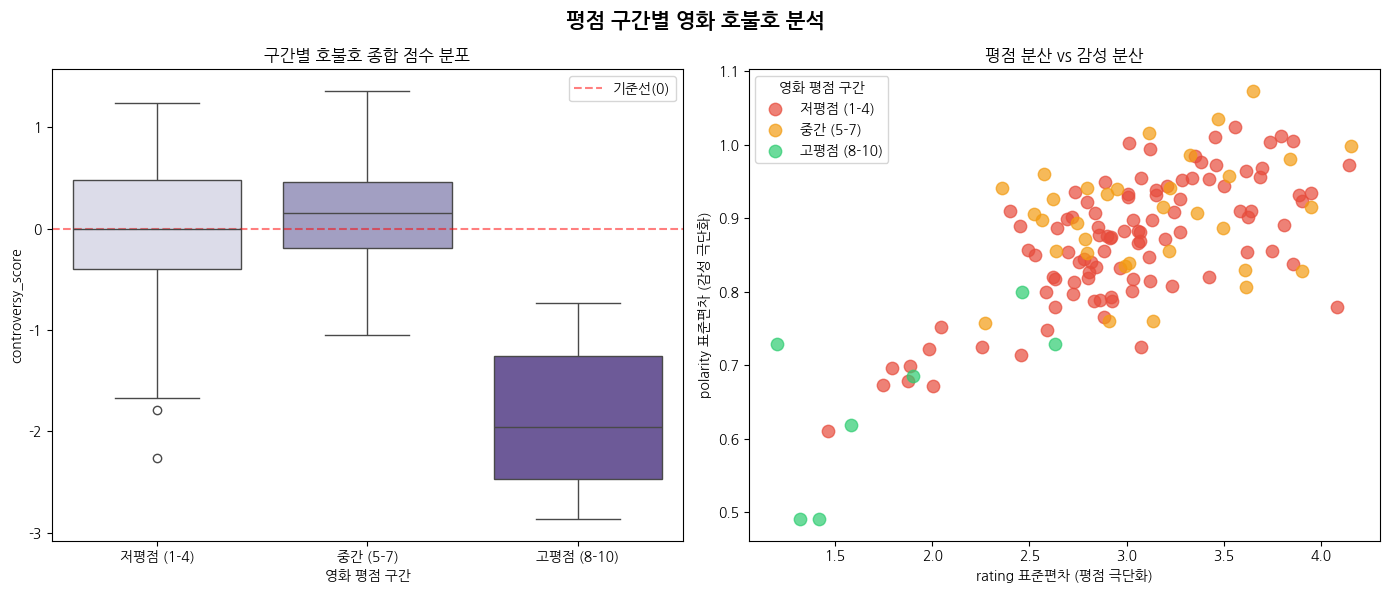

In [13]:
group_order = ['저평점 (1-4)', '중간 (5-7)', '고평점 (8-10)']
movie_stats['movie_rating_group'] = pd.Categorical(
    movie_stats['movie_rating_group'], categories=group_order, ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('평점 구간별 영화 호불호 분석', fontsize=15, fontweight='bold')

# 시각화 1: 구간별 controversy_score 박스플롯
sns.boxplot(data=movie_stats, x='movie_rating_group', y='controversy_score',
            order=group_order, ax=axes[0], palette='Purples')
axes[0].set_title('구간별 호불호 종합 점수 분포')
axes[0].set_xlabel('영화 평점 구간')
axes[0].set_ylabel('controversy_score')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='기준선(0)')
axes[0].legend()

# 시각화 2: rating 분산 vs polarity 분산 산점도
colors = {'저평점 (1-4)': '#e74c3c', '중간 (5-7)': '#f39c12', '고평점 (8-10)': '#2ecc71'}
for group in group_order:
    subset = movie_stats[movie_stats['movie_rating_group'] == group]
    axes[1].scatter(subset['rating_std'], subset['polarity_std'],
                    label=group, color=colors[group], alpha=0.7, s=80)

axes[1].set_xlabel('rating 표준편차 (평점 극단화)')
axes[1].set_ylabel('polarity 표준편차 (감성 극단화)')
axes[1].set_title('평점 분산 vs 감성 분산')
axes[1].legend(title='영화 평점 구간')

plt.tight_layout()
plt.savefig('controversy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 결과 해석

1. **중간 평점(5-7)에서 호불호가 가장 심하다** — 타입B 영화 비율이 가장 높고 평균 controversy_score도 가장 높음
2. **고평점 영화는 예외 없이 일관된 긍정 평가** — 7개 모두 타입A, 평균 -1.86
3. **저평점 영화는 두 타입이 공존** — "모두가 동의하는 나쁜 영화"와 "평가가 극단적으로 갈리는 영화"가 반반

In [30]:
# 결과 해석 1: controversy_score 기술통계
print("=== 구간별 controversy_score 통계 ===")
group_stats = movie_stats.groupby('movie_rating_group', observed=True)['controversy_score'].agg(
    평균='mean', 최대='max', 최소='min'
).reindex(group_order).round(3)
print(group_stats)

# 결과 해석 2: review_count와 상관관계 확인
print("\n=== controversy_score와 review_count 상관관계 ===")
corr = movie_stats[['controversy_score', 'review_count']].corr().round(4) # 기본값 - 피어슨 상관계수
print(corr)
print(f"\n✅ 상관계수 {corr.loc['controversy_score','review_count']:.4f}: 리뷰 수는 호불호 점수에 거의 영향 없음\n")

# 결과 해석 3: 구간 내 타입 분류
for group in group_order:
    group_data = movie_stats[movie_stats['movie_rating_group'] == group].copy()
    group_data['타입'] = group_data['controversy_score'].apply(
        lambda x: '타입B (호불호 심함)' if x > 0 else '타입A (일관된 평가)'
    )
    print(f"=== {group} 구간 내 호불호 심한 영화 vs 일관된 영화 ===")
    print(group_data['타입'].value_counts())
    print()
    print(group_data.groupby('타입')[['rating_std', 'polarity_std', 'controversy_score']].mean().round(4))
    print()

=== 구간별 controversy_score 통계 ===
                       평균     최대     최소
movie_rating_group                     
저평점 (1-4)          -0.038  1.244 -2.265
중간 (5-7)            0.197  1.362 -1.050
고평점 (8-10)         -1.860 -0.730 -2.870

=== controversy_score와 review_count 상관관계 ===
                   controversy_score  review_count
controversy_score             1.0000       -0.1518
review_count                 -0.1518        1.0000

✅ 상관계수 -0.1518: 리뷰 수는 호불호 점수에 거의 영향 없음

=== 저평점 (1-4) 구간 내 호불호 심한 영화 vs 일관된 영화 ===
타입
타입A (일관된 평가)    51
타입B (호불호 심함)    49
Name: count, dtype: int64

              rating_std  polarity_std  controversy_score
타입                                                       
타입A (일관된 평가)      2.6406        0.8072            -0.5674
타입B (호불호 심함)      3.4057        0.9296             0.5136

=== 중간 (5-7) 구간 내 호불호 심한 영화 vs 일관된 영화 ===
타입
타입B (호불호 심함)    20
타입A (일관된 평가)    13
Name: count, dtype: int64

              rating_std  polarity_std  controversy_score
타입             